# Project 2 - Exploratory Data Analysis (EDA)

# Objective
Perform exploratory data analysis on the e-commerce dataset to find statistics, trends, and outliers.


# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset

In [2]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Dataset Information

In [3]:
df.shape

(1200, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


# Missing Values

In [5]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Only CouponCode has 309 missing values because some customers did not use a coupon code. All other columns are completely filled.


# Duplicate Rows

In [6]:
df.duplicated().sum()

np.int64(0)

There are 0 duplicate rows in the dataset.


# Descriptive Statistics

In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
print("TotalPrice Mean:", df['TotalPrice'].mean())
print("TotalPrice Median:", df['TotalPrice'].median())
print("TotalPrice Mode:", df['TotalPrice'].mode()[0])


TotalPrice Mean: 1053.9683
TotalPrice Median: 823.615
TotalPrice Mode: 211.14


The average order total is around $1053.97 while the median is $823.62. The average is higher because of a few high value orders.


# Data Analysis

In [9]:
# Most ordered products
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [10]:
# Total revenue by product
revenue_by_product = df.groupby('Product')['TotalPrice'].sum()
revenue_by_product

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64

In [11]:
# Order status counts
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [12]:
# Payment methods
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Printers and Tablets have the highest order counts. Chairs, Printers, and Laptops generated the most total revenue. Cancelled and Returned orders make up a large portion of overall orders.


# Visualizations

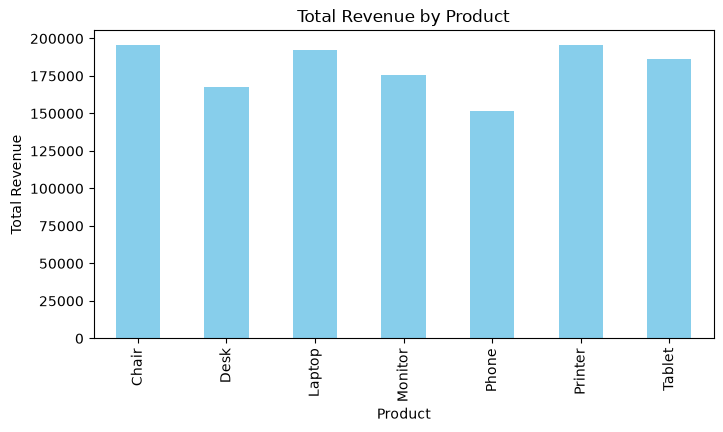

In [13]:
# Bar chart for revenue by product
plt.figure(figsize=(8, 4))
revenue_by_product.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.show()


This bar chart shows that Chair, Printer, and Laptop generated the highest total revenue, each making close to $195,000.


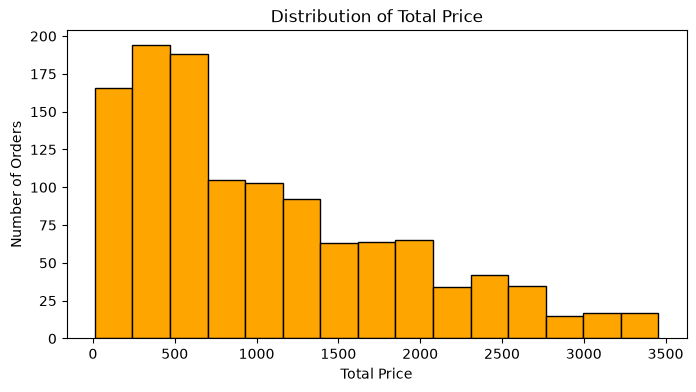

In [14]:
# Histogram for Total Price distribution
plt.figure(figsize=(8, 4))
plt.hist(df['TotalPrice'], bins=15, color='orange', edgecolor='black')
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Number of Orders')
plt.show()


This histogram shows that most orders have a total price below $1500, with fewer orders having higher totals.


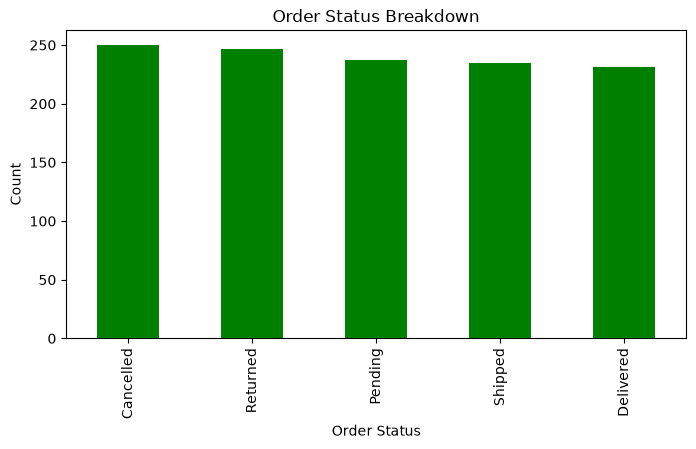

In [15]:
# Bar chart for order status
plt.figure(figsize=(8, 4))
df['OrderStatus'].value_counts().plot(kind='bar', color='green')
plt.title('Order Status Breakdown')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.show()


This chart shows the distribution of order statuses. Cancelled and Returned orders are almost as high as Shipped and Delivered orders.


# Outliers

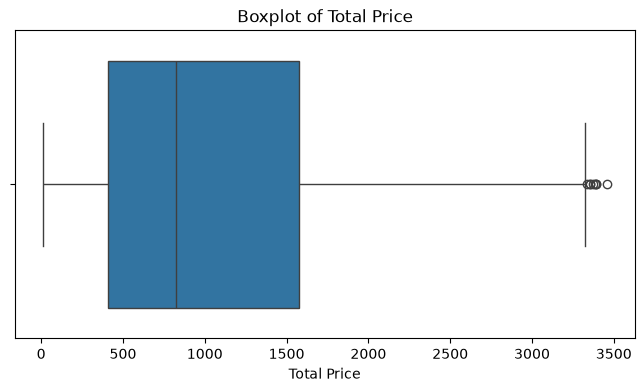

In [16]:
# Boxplot for Total Price
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalPrice'])
plt.title('Boxplot of Total Price')
plt.xlabel('Total Price')
plt.show()


In [17]:
q1 = df['TotalPrice'].quantile(0.25)
q3 = df['TotalPrice'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = df[df['TotalPrice'] > upper_bound]
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))


Upper Bound: 3330.4075
Number of outliers: 8


The boxplot shows a few data points past the upper limit. Using the IQR method, we found 8 orders above $3330.41, which are orders where 5 items of expensive products were bought.


# Key Observations
1. The dataset has 1200 rows and 14 columns with 0 duplicate rows.
2. Printer is the most ordered product (181 orders), while Chair generated the most revenue ($195,620.11).
3. The average order total is $1053.97 and the median is $823.62.
4. Cancelled (250) and Returned (247) orders make up about 41.4% of all orders.
5. Most orders have between 1 to 5 items.
6. Instagram was the top referral source with 259 orders.
7. There are 8 high-value outliers in Total Price caused by bulk orders of expensive items.


# Conclusion
The dataset is clean and complete. Sales revenue is balanced across product categories and referral channels. However, there is a high rate of order cancellations and returns that could be improved.
